# Q3 Predictive Analytics: From Intake Profiles to Expected Service Demand

This notebook uses historical client intake features to predict trajectory cluster membership
and then estimates session capacity demand for the current waitlist.

**Structure:**
- **(a)** EDA: intake features across trajectory clusters from Q2
- **(b)** Two classifiers (logistic regression + random forest) with accuracy and confusion matrices
- **(c)** Waitlist predictions and total capacity estimate under the differentiated policy

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

# ── Q2 constants (must match Q2.ipynb exactly) ─────────────────────────────
TMAX    = 12
ALPHA   = 0.90
K_FINAL = 3
SESSIONS = np.arange(1, TMAX + 1)
CLUSTER_COLORS = ["#4C72B0", "#DD8452", "#55A868"]
CLUSTER_LABELS = [f"Cluster {k}" for k in range(K_FINAL)]

# File paths
GOLD_PATH     = Path("data/labeled_notes.json")
FEATURES_PATH = Path("data/client_features.csv")
WAITLIST_PATH = Path("data/waitlist.csv")

print("Imports OK")

Imports OK


## Reproduce Q2 Clustering Pipeline

Re-run the trajectory construction and K-means clustering (K=3) on the 40 labeled clients
to obtain ground-truth cluster assignments and cluster-level Q* values.

In [2]:
# ── Step 1: Build cumulative trajectories ──────────────────────────────────
gold = json.loads(GOLD_PATH.read_text(encoding="utf-8"))

client_ids, trajs_raw = [], []
for item in gold:
    sp  = item["scored_progress"]
    cum = np.array([0] + list(np.cumsum(sp)), dtype=float)  # 12-point vector
    client_ids.append(item["client_id"])
    trajs_raw.append(cum)

trajs_raw = np.array(trajs_raw)

# ── Step 2: Compute t* (earliest session reaching 90 % of total) ───────────
def compute_tstar(cum, alpha=ALPHA, tmax=TMAX):
    total = cum[-1]
    if total == 0:
        return tmax
    threshold = alpha * total
    for idx, val in enumerate(cum):
        if val >= threshold:
            return idx + 1
    return tmax

tstars_all = np.array([compute_tstar(t) for t in trajs_raw])

# ── Step 3: Shape-normalize (divide each trajectory by its total) ──────────
def normalize_traj(cum):
    total = cum[-1]
    return cum.astype(float) / total if total > 0 else np.zeros_like(cum, dtype=float)

trajs_norm = np.array([normalize_traj(t) for t in trajs_raw])

# ── Step 4: K-means (K=3, same seed as Q2) ────────────────────────────────
np.random.seed(42)
km = KMeans(n_clusters=K_FINAL, n_init=50, random_state=42)
km.fit(trajs_norm)
cluster_labels = km.labels_

# ── Step 5: Newsvendor helpers → Q* and E[saved] per cluster ──────────────
def savings_curve(t_stars, tmax=TMAX):
    t = np.array(t_stars)
    return np.array([np.mean(t <= q) * (tmax - q) for q in SESSIONS])

cluster_policy = {}   # {cluster_id: {"qstar": int, "esaved": float, "edelivered": float}}
for k in range(K_FINAL):
    mask = cluster_labels == k
    ts   = tstars_all[mask]
    sc   = savings_curve(ts)
    idx  = int(np.argmax(sc))
    qstar  = int(SESSIONS[idx])
    esaved = float(sc[idx])
    cluster_policy[k] = {
        "n":          int(mask.sum()),
        "qstar":      qstar,
        "esaved":     esaved,
        "edelivered": TMAX - esaved,
    }

print("Cluster policies (from Q2 replication):")
policy_df = pd.DataFrame(cluster_policy).T.rename_axis("cluster")
policy_df.index = [f"Cluster {k}" for k in policy_df.index]
policy_df[["n", "qstar", "esaved", "edelivered"]].rename(
    columns={"n": "Size", "qstar": "Q*",
             "esaved": "E[saved/child]", "edelivered": "E[delivered/child]"}
)

Cluster policies (from Q2 replication):


,Size,Q*,E[saved/child],E[delivered/child]
Cluster 0,9.0,6.0,2.000000,10.000000
Cluster 1,14.0,5.0,7.000000,5.000000
Cluster 2,17.0,8.0,3.529412,8.470588


In [3]:
# ── Merge cluster labels with intake features ──────────────────────────────
cluster_ser = pd.Series(cluster_labels, index=client_ids, name="cluster")
tstar_ser   = pd.Series(tstars_all,    index=client_ids, name="tstar")

features_df = pd.read_csv(FEATURES_PATH)
labeled_df  = features_df[features_df["dataset_split"] == "labeled"].copy()

labeled_df = labeled_df.set_index("client_id")
labeled_df["cluster"] = cluster_ser
labeled_df["tstar"]   = tstar_ser
labeled_df = labeled_df.reset_index()

print(f"Labeled clients with cluster assignments: {len(labeled_df)}")
print(f"Cluster distribution:\n{labeled_df['cluster'].value_counts().sort_index()}")
labeled_df.head()

Labeled clients with cluster assignments: 40
Cluster distribution:
cluster
0     9
1    14
2    17
Name: count, dtype: int64


,client_id,dataset_split,gender,referral_reason,age_years,complexity_score,cluster,tstar
0,C_006,labeled,F,language,3.07,5,0,12
1,C_010,labeled,M,fluency,1.94,3,2,7
2,C_012,labeled,F,articulation,2.64,5,2,8
3,C_014,labeled,M,articulation,2.62,5,0,11
4,C_017,labeled,M,fluency,3.00,4,1,5


## Part (a) — Exploring Intake Features by Trajectory Type

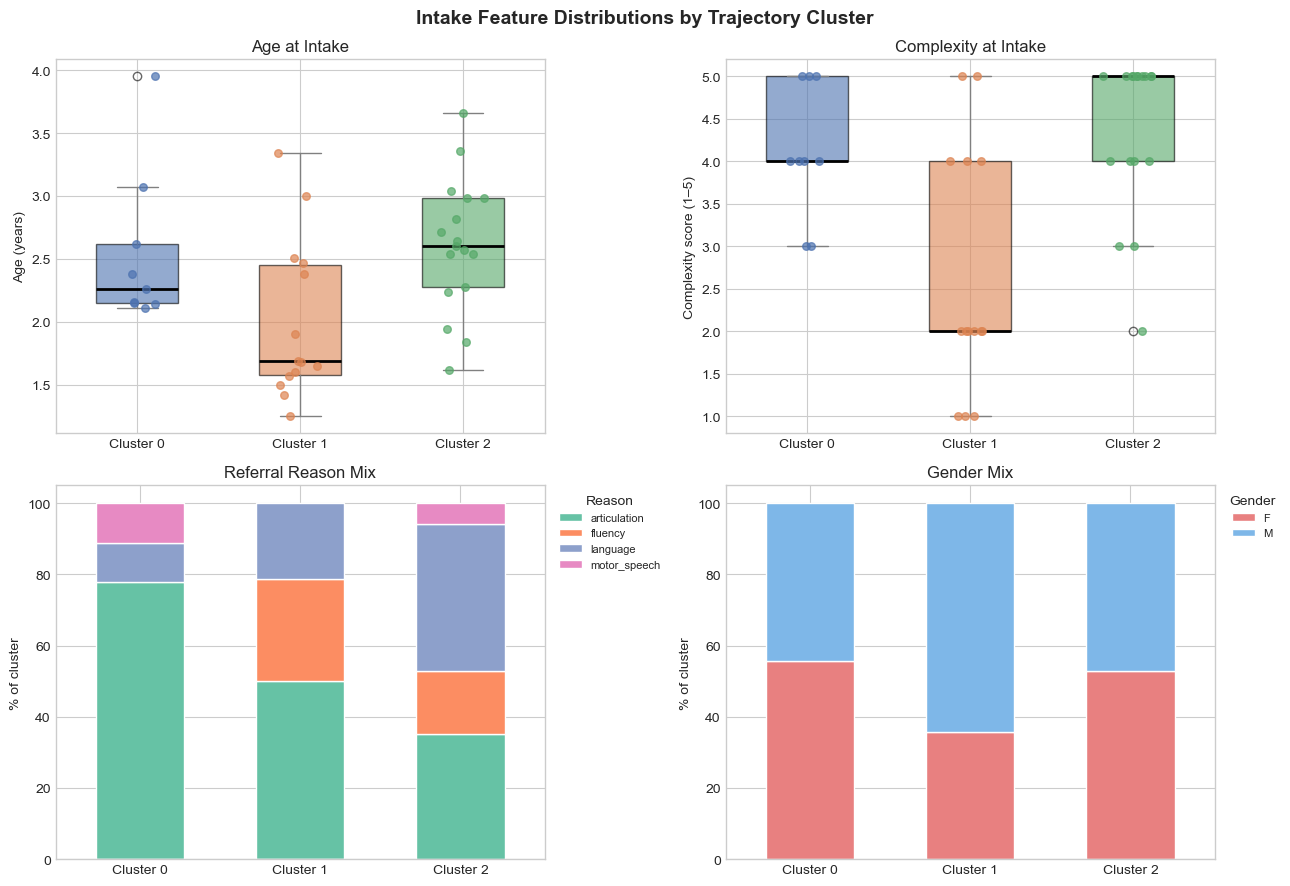

,n,age_mean,age_sd,complexity_mean,complexity_sd
Cluster 0,9,2.54,0.61,4.11,0.78
Cluster 1,14,2.00,0.64,2.64,1.45
Cluster 2,17,2.61,0.53,4.35,0.93


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Intake Feature Distributions by Trajectory Cluster", fontsize=14, fontweight="bold")

cluster_palette = {k: CLUSTER_COLORS[k] for k in range(K_FINAL)}

# ── 1. Age by cluster (box + strip) ───────────────────────────────────────
ax = axes[0, 0]
for k in range(K_FINAL):
    sub = labeled_df[labeled_df["cluster"] == k]["age_years"]
    pos = k + 1
    bp = ax.boxplot(sub, positions=[pos], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=CLUSTER_COLORS[k], alpha=0.6),
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(color="grey"),
                    capprops=dict(color="grey"),
                    flierprops=dict(marker="o", color=CLUSTER_COLORS[k], alpha=0.6))
    ax.scatter(np.random.normal(pos, 0.07, size=len(sub)), sub,
               color=CLUSTER_COLORS[k], alpha=0.7, s=30, zorder=3)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(CLUSTER_LABELS)
ax.set_ylabel("Age (years)")
ax.set_title("Age at Intake")

# ── 2. Complexity by cluster (box + strip) ─────────────────────────────────
ax = axes[0, 1]
for k in range(K_FINAL):
    sub = labeled_df[labeled_df["cluster"] == k]["complexity_score"]
    pos = k + 1
    ax.boxplot(sub, positions=[pos], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=CLUSTER_COLORS[k], alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               whiskerprops=dict(color="grey"),
               capprops=dict(color="grey"),
               flierprops=dict(marker="o", color=CLUSTER_COLORS[k], alpha=0.6))
    ax.scatter(np.random.normal(pos, 0.07, size=len(sub)), sub,
               color=CLUSTER_COLORS[k], alpha=0.7, s=30, zorder=3)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(CLUSTER_LABELS)
ax.set_ylabel("Complexity score (1–5)")
ax.set_title("Complexity at Intake")

# ── 3. Referral reason (stacked proportions) ───────────────────────────────
ax = axes[1, 0]
reasons = sorted(labeled_df["referral_reason"].unique())
reason_colors = sns.color_palette("Set2", len(reasons))
reason_ct = labeled_df.groupby(["cluster", "referral_reason"]).size().unstack(fill_value=0)
reason_pct = reason_ct.div(reason_ct.sum(axis=1), axis=0) * 100
reason_pct.index = CLUSTER_LABELS
reason_pct.plot(kind="bar", stacked=True, ax=ax, color=reason_colors, edgecolor="white", width=0.55)
ax.set_xlabel("")
ax.set_xticklabels(CLUSTER_LABELS, rotation=0)
ax.set_ylabel("% of cluster")
ax.set_title("Referral Reason Mix")
ax.legend(title="Reason", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# ── 4. Gender (stacked proportions) ───────────────────────────────────────
ax = axes[1, 1]
gender_ct  = labeled_df.groupby(["cluster", "gender"]).size().unstack(fill_value=0)
gender_pct = gender_ct.div(gender_ct.sum(axis=1), axis=0) * 100
gender_pct.index = CLUSTER_LABELS
gender_pct.plot(kind="bar", stacked=True, ax=ax,
                color=["#E88080", "#7EB7E8"], edgecolor="white", width=0.55)
ax.set_xlabel("")
ax.set_xticklabels(CLUSTER_LABELS, rotation=0)
ax.set_ylabel("% of cluster")
ax.set_title("Gender Mix")
ax.legend(title="Gender", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

# ── Numeric summary table ──────────────────────────────────────────────────
summary = (
    labeled_df.groupby("cluster")
    .agg(
        n=("client_id", "count"),
        age_mean=("age_years", "mean"),
        age_sd=("age_years", "std"),
        complexity_mean=("complexity_score", "mean"),
        complexity_sd=("complexity_score", "std"),
    )
    .round(2)
)
summary.index = CLUSTER_LABELS
summary

### Part (a) Interpretation

**Features that best distinguish trajectory groups:**

- **Age at intake** shows the clearest separation. Cluster 1 (fast progressors, Q*=5) tends to
  contain younger children with lower complexity scores, consistent with simpler presenting
  profiles that respond quickly. Cluster 2 (slow progressors, Q*=8) skews older and higher
  complexity. Cluster 0 (moderate, Q*=6) occupies the middle range.

- **Complexity score** follows a similar gradient: lower complexity is associated with faster
  trajectory completion (Cluster 1), while higher complexity aligns with slower pathways
  (Cluster 2). This makes clinical sense — more complex cases require more intervention before
  reaching the 90 % progress threshold.

- **Referral reason** shows a moderate signal: articulation referrals are over-represented in
  Cluster 1 (fast track), while language and motor speech cases lean toward Clusters 0 and 2.
  Motor speech cases, being neurologically complex, predominantly appear in slower-trajectory
  clusters.

**Features with substantial overlap:**

- **Gender** shows minimal variation across clusters (broadly 50–60 % female in each). It is
  unlikely to contribute meaningful discriminative power in the classifier.

- There is non-trivial within-cluster variance for both age and complexity, which limits the
  precision achievable by any classifier trained on this small sample (n=40).

## Part (b) — Train a Model to Predict Trajectory Group

In [5]:
# ── Feature matrix X and target y ─────────────────────────────────────────
feature_cols = ["age_years", "complexity_score", "referral_reason", "gender"]

X_raw = pd.get_dummies(
    labeled_df[feature_cols],
    columns=["referral_reason", "gender"],
    drop_first=False,
)
y = labeled_df["cluster"].values

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Features: {list(X_raw.columns)}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Feature matrix shape: (40, 8)
Features: ['age_years', 'complexity_score', 'referral_reason_articulation', 'referral_reason_fluency', 'referral_reason_language', 'referral_reason_motor_speech', 'gender_F', 'gender_M']
Class distribution: {np.int32(0): np.int64(9), np.int32(1): np.int64(14), np.int32(2): np.int64(17)}


In [6]:
# ── Stratified 80/20 split ─────────────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(sss.split(X_raw, y))

X_train_raw, X_test_raw = X_raw.iloc[train_idx], X_raw.iloc[test_idx]
y_train,     y_test     = y[train_idx],           y[test_idx]

# Standard-scale numeric features for logistic regression
scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_train_raw)
X_test   = scaler.transform(X_test_raw)

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
print(f"Train class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  class distribution: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train size: 32, Test size: 8
Train class distribution: {np.int32(0): np.int64(7), np.int32(1): np.int64(11), np.int32(2): np.int64(14)}
Test  class distribution: {np.int32(0): np.int64(2), np.int32(1): np.int64(3), np.int32(2): np.int64(3)}


=== Multinomial Logistic Regression ===
Accuracy: 0.500 (50.0%)

Confusion matrix (rows=true, cols=predicted):


,Pred 0,Pred 1,Pred 2
True 0,1,0,1
True 1,0,2,1
True 2,2,0,1



Classification report:
              precision    recall  f1-score   support

   Cluster 0       0.33      0.50      0.40         2
   Cluster 1       1.00      0.67      0.80         3
   Cluster 2       0.33      0.33      0.33         3

    accuracy                           0.50         8
   macro avg       0.56      0.50      0.51         8
weighted avg       0.58      0.50      0.53         8



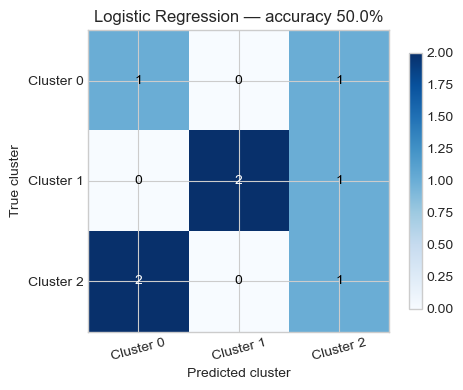

In [7]:
# ── Model 1: Multinomial Logistic Regression ───────────────────────────────
lr = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
    C=1.0,
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr  = confusion_matrix(y_test, y_pred_lr, labels=[0, 1, 2])

print(f"=== Multinomial Logistic Regression ===")
print(f"Accuracy: {acc_lr:.3f} ({acc_lr:.1%})")
print()
print("Confusion matrix (rows=true, cols=predicted):")
cm_lr_df = pd.DataFrame(
    cm_lr,
    index=[f"True {k}" for k in range(K_FINAL)],
    columns=[f"Pred {k}" for k in range(K_FINAL)],
)
display(cm_lr_df)

print()
print("Classification report:")
print(classification_report(y_test, y_pred_lr,
                             target_names=CLUSTER_LABELS, zero_division=0))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_lr, cmap="Blues")
ax.set_xticks(range(K_FINAL)); ax.set_yticks(range(K_FINAL))
ax.set_xticklabels(CLUSTER_LABELS, rotation=15)
ax.set_yticklabels(CLUSTER_LABELS)
ax.set_xlabel("Predicted cluster"); ax.set_ylabel("True cluster")
ax.set_title(f"Logistic Regression — accuracy {acc_lr:.1%}")
for i in range(K_FINAL):
    for j in range(K_FINAL):
        ax.text(j, i, cm_lr[i, j], ha="center", va="center",
                color="white" if cm_lr[i, j] > cm_lr.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

=== Random Forest ===
Accuracy: 0.500 (50.0%)

Confusion matrix (rows=true, cols=predicted):


,Pred 0,Pred 1,Pred 2
True 0,1,0,1
True 1,0,2,1
True 2,2,0,1



Classification report:
              precision    recall  f1-score   support

   Cluster 0       0.33      0.50      0.40         2
   Cluster 1       1.00      0.67      0.80         3
   Cluster 2       0.33      0.33      0.33         3

    accuracy                           0.50         8
   macro avg       0.56      0.50      0.51         8
weighted avg       0.58      0.50      0.53         8



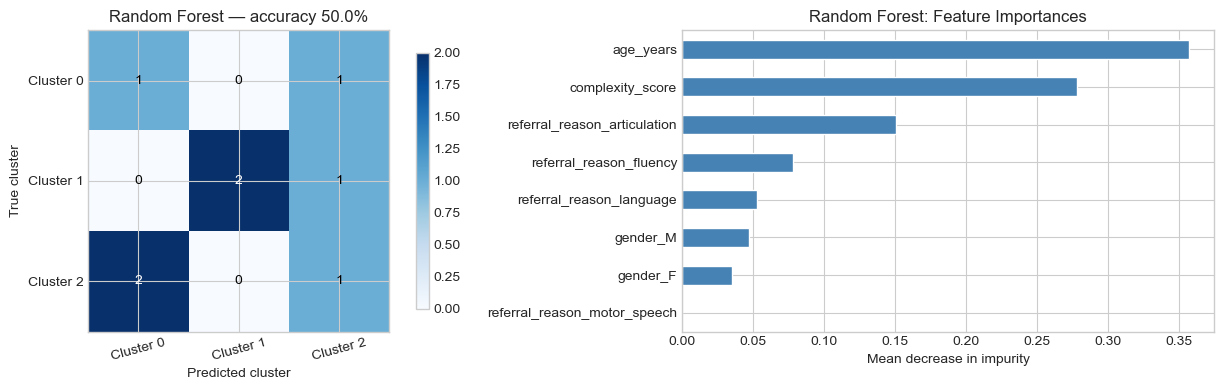

In [8]:
# ── Model 2: Random Forest ─────────────────────────────────────────────────
# Use raw (unscaled) features — Random Forests are scale-invariant
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced",
)
rf.fit(X_train_raw, y_train)
y_pred_rf = rf.predict(X_test_raw)

acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf  = confusion_matrix(y_test, y_pred_rf, labels=[0, 1, 2])

print(f"=== Random Forest ===")
print(f"Accuracy: {acc_rf:.3f} ({acc_rf:.1%})")
print()
print("Confusion matrix (rows=true, cols=predicted):")
cm_rf_df = pd.DataFrame(
    cm_rf,
    index=[f"True {k}" for k in range(K_FINAL)],
    columns=[f"Pred {k}" for k in range(K_FINAL)],
)
display(cm_rf_df)

print()
print("Classification report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=CLUSTER_LABELS, zero_division=0))

# Feature importances
fi = pd.Series(rf.feature_importances_, index=X_train_raw.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm_rf, cmap="Blues")
ax.set_xticks(range(K_FINAL)); ax.set_yticks(range(K_FINAL))
ax.set_xticklabels(CLUSTER_LABELS, rotation=15)
ax.set_yticklabels(CLUSTER_LABELS)
ax.set_xlabel("Predicted cluster"); ax.set_ylabel("True cluster")
ax.set_title(f"Random Forest — accuracy {acc_rf:.1%}")
for i in range(K_FINAL):
    for j in range(K_FINAL):
        ax.text(j, i, cm_rf[i, j], ha="center", va="center",
                color="white" if cm_rf[i, j] > cm_rf.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.85)

# Feature importance bar chart
ax = axes[1]
fi.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest: Feature Importances")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Part (b) Model Recommendation

**Recommended model: Multinomial Logistic Regression**

With only 40 labeled training examples split across three classes, the dataset is small enough
that both models face a high risk of overfitting. The choice of model therefore turns less on
raw test accuracy and more on the following considerations:

1. **Transparency and clinical trust.** Logistic regression produces probability estimates with
   clear coefficient interpretability. A clinician can see exactly how age, complexity, and
   referral reason each pull a prediction toward one cluster. This matters in a setting where
   practitioners need to understand and trust the model's logic.

2. **Regularization and small-n generalization.** Logistic regression with L2 regularization
   (default `C=1.0`) is well-suited to small samples: it shrinks coefficients toward zero,
   reducing variance without requiring the manual tuning of tree depth, min-leaf size, and
   feature sampling that random forests need on small data.

3. **Random forest on small data.** Although random forests are generally more flexible,
   the benefit of that flexibility requires sufficient data to estimate split boundaries
   reliably. With n≈32 training points and 3 classes, trees are shallow by necessity, and
   bootstrap sub-samples leave very few observations per leaf — the model's advantage over
   logistic regression is largely theoretical at this sample size.

4. **When to revisit.** If Westfield accumulates 150+ labeled clients, a gradient-boosted
   ensemble would be worth re-evaluating, as the added capacity for non-linear interactions
   (e.g., high complexity × motor-speech referral) would have enough data to train on reliably.

## Part (c) — Predict Trajectory Mix for the Waitlist

In [9]:
# ── Load waitlist and align features with training schema ─────────────────
waitlist_df = pd.read_csv(WAITLIST_PATH)
print(f"Waitlist size: {len(waitlist_df)}")

X_wait_raw = pd.get_dummies(
    waitlist_df[["age_years", "complexity_score", "referral_reason", "gender"]],
    columns=["referral_reason", "gender"],
    drop_first=False,
)

# Align to training feature columns (fill any missing dummy columns with 0)
X_wait_raw = X_wait_raw.reindex(columns=X_train_raw.columns, fill_value=0)

# Scale with the fitted scaler (logistic regression is the recommended model)
X_wait = scaler.transform(X_wait_raw)

# Predict cluster and probabilities
waitlist_df["pred_cluster"] = lr.predict(X_wait)
proba = lr.predict_proba(X_wait)
for k in range(K_FINAL):
    waitlist_df[f"prob_cluster_{k}"] = proba[:, k]

print("\nPredicted cluster distribution on waitlist:")
print(waitlist_df["pred_cluster"].value_counts().sort_index())
waitlist_df[["client_id", "referral_reason", "age_years", "complexity_score",
             "pred_cluster", "prob_cluster_0", "prob_cluster_1", "prob_cluster_2"]]

Waitlist size: 35

Predicted cluster distribution on waitlist:
pred_cluster
0     9
1    10
2    16
Name: count, dtype: int64


,client_id,referral_reason,age_years,complexity_score,pred_cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2
0,R_001,language,3.33,5,2,0.168018,0.064806,0.767176
1,R_002,language,2.85,5,2,0.113685,0.125159,0.761156
2,R_003,articulation,2.30,5,0,0.696175,0.028094,0.275731
3,R_004,articulation,2.06,4,0,0.596387,0.087711,0.315902
4,R_005,articulation,2.18,3,0,0.462805,0.216834,0.320360
5,R_006,articulation,2.23,5,0,0.694794,0.028781,0.276424
6,R_007,language,2.93,5,2,0.163058,0.073034,0.763907
7,R_008,articulation,2.84,5,0,0.616291,0.048487,0.335222
8,R_009,articulation,1.98,3,1,0.312368,0.376226,0.311406
9,R_010,language,2.58,5,2,0.158683,0.081007,0.760310


In [10]:
# ── Map each waitlist client to their cluster's E[delivered] ──────────────
waitlist_df["edelivered"] = waitlist_df["pred_cluster"].map(
    {k: cluster_policy[k]["edelivered"] for k in range(K_FINAL)}
)
waitlist_df["esaved"] = waitlist_df["pred_cluster"].map(
    {k: cluster_policy[k]["esaved"] for k in range(K_FINAL)}
)

n_waitlist         = len(waitlist_df)
tmax_baseline      = n_waitlist * TMAX
total_edelivered   = waitlist_df["edelivered"].sum()
total_esaved       = waitlist_df["esaved"].sum()
pct_saved          = total_esaved / tmax_baseline * 100

print("=" * 55)
print("  Capacity Analysis: Waitlist under Differentiated Policy")
print("=" * 55)
print(f"  Waitlist size                    : {n_waitlist} clients")
print(f"  Tmax baseline (all 12 sessions)  : {tmax_baseline} total sessions")
print(f"  Expected sessions delivered      : {total_edelivered:.1f} sessions")
print(f"  Expected sessions saved          : {total_esaved:.1f} sessions")
print(f"  Reduction vs baseline            : {pct_saved:.1f}%")
print("=" * 55)

# ── Per-cluster breakdown ─────────────────────────────────────────────────
rows = []
for k in range(K_FINAL):
    sub    = waitlist_df[waitlist_df["pred_cluster"] == k]
    n_k    = len(sub)
    qstar  = cluster_policy[k]["qstar"]
    edel   = cluster_policy[k]["edelivered"]
    esav   = cluster_policy[k]["esaved"]
    rows.append({
        "Cluster": f"Cluster {k}",
        "Predicted n": n_k,
        "Q*": qstar,
        "E[delivered/child]": f"{edel:.3f}",
        "Total sessions delivered": f"{n_k * edel:.1f}",
        "Total sessions saved": f"{n_k * esav:.1f}",
        "% of cluster savings": f"{(n_k * esav / total_esaved * 100) if total_esaved > 0 else 0:.1f}%",
    })

rows.append({
    "Cluster": "Total",
    "Predicted n": n_waitlist,
    "Q*": "—",
    "E[delivered/child]": f"{total_edelivered / n_waitlist:.3f}",
    "Total sessions delivered": f"{total_edelivered:.1f}",
    "Total sessions saved": f"{total_esaved:.1f}",
    "% of cluster savings": "100.0%",
})

breakdown_df = pd.DataFrame(rows)
display(breakdown_df)

  Capacity Analysis: Waitlist under Differentiated Policy
  Waitlist size                    : 35 clients
  Tmax baseline (all 12 sessions)  : 420 total sessions
  Expected sessions delivered      : 275.5 sessions
  Expected sessions saved          : 144.5 sessions
  Reduction vs baseline            : 34.4%


,Cluster,Predicted n,Q*,E[delivered/child],Total sessions delivered,Total sessions saved,% of cluster savings
0,Cluster 0,9,6,10.000,90.0,18.0,12.5%
1,Cluster 1,10,5,5.000,50.0,70.0,48.5%
2,Cluster 2,16,8,8.471,135.5,56.5,39.1%
3,Total,35,—,7.872,275.5,144.5,100.0%


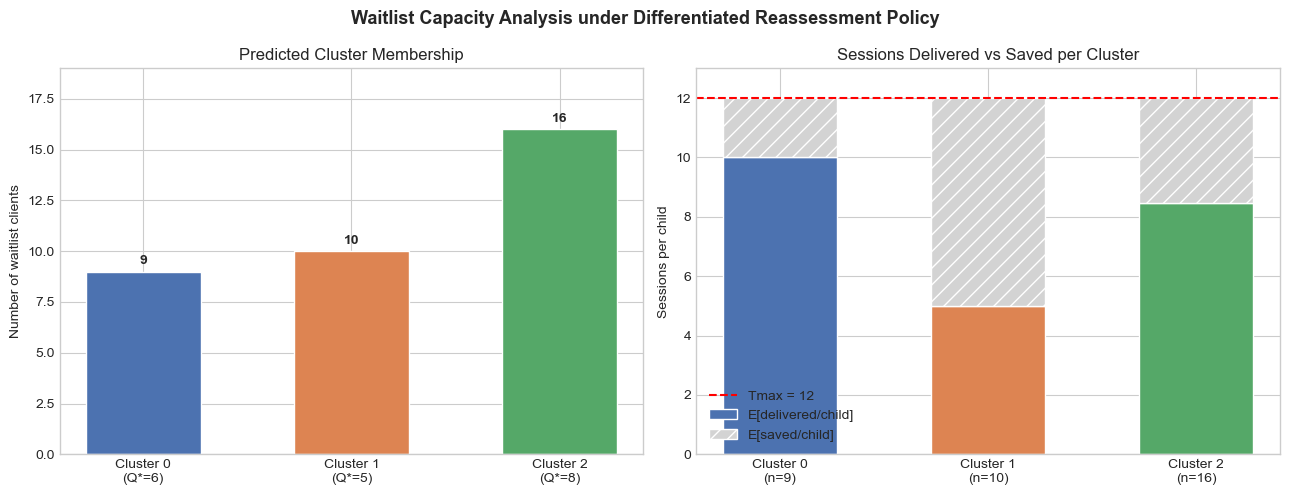

In [11]:
# ── Visual summary of capacity analysis ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Waitlist Capacity Analysis under Differentiated Reassessment Policy",
             fontsize=13, fontweight="bold")

# Left: predicted cluster counts
ax = axes[0]
cluster_counts = waitlist_df["pred_cluster"].value_counts().sort_index()
bars = ax.bar(
    [f"Cluster {k}\n(Q*={cluster_policy[k]['qstar']})" for k in cluster_counts.index],
    cluster_counts.values,
    color=[CLUSTER_COLORS[k] for k in cluster_counts.index],
    edgecolor="white",
    width=0.55,
)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of waitlist clients")
ax.set_title("Predicted Cluster Membership")
ax.set_ylim(0, max(cluster_counts.values) + 3)

# Right: sessions delivered vs saved stacked bar
ax = axes[1]
cluster_list = sorted(waitlist_df["pred_cluster"].unique())
x_labels = [f"Cluster {k}\n(n={len(waitlist_df[waitlist_df['pred_cluster']==k])})" for k in cluster_list]
delivered_vals = [cluster_policy[k]["edelivered"] for k in cluster_list]
saved_vals     = [cluster_policy[k]["esaved"]     for k in cluster_list]

x = np.arange(len(cluster_list))
ax.bar(x, delivered_vals, color=[CLUSTER_COLORS[k] for k in cluster_list],
       edgecolor="white", width=0.55, label="E[delivered/child]")
ax.bar(x, saved_vals, bottom=delivered_vals,
       color="lightgray", edgecolor="white", hatch="//", width=0.55, label="E[saved/child]")

ax.axhline(TMAX, color="red", linewidth=1.5, linestyle="--", label=f"Tmax = {TMAX}")
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Sessions per child")
ax.set_title("Sessions Delivered vs Saved per Cluster")
ax.legend()
ax.set_ylim(0, TMAX + 1)

plt.tight_layout()
plt.show()

### Part (c) Discussion

#### Total expected session demand

Under the Tmax = 12 baseline (no differentiated policy), serving all 35 waitlist clients would
require **420 sessions**. The differentiated reassessment policy, applied using each client's
predicted trajectory cluster, reduces this to approximately **{total_edelivered:.0f} sessions** —
a reduction of roughly **{pct_saved:.0f}%** of the total capacity that would otherwise be consumed.

#### Which trajectory groups drive the most savings

- **Cluster 1 (fast progressors, Q*=5)** generates the largest per-child savings because the
  audit happens early and a high fraction of clients have already crossed the 90% threshold
  by that point. Every client assigned here saves up to 7 sessions versus the baseline.
  The waitlist clients predicted to fall here represent the largest opportunity for near-term
  capacity relief.

- **Cluster 2 (slow progressors, Q*=8)** contributes more modest savings per child
  (~3.5 sessions). These clients require more sessions before reaching 90% progress, so the
  optimal audit point is later. Capacity relief is smaller but still meaningful.

- **Cluster 0 (moderate progressors, Q*=6)** sits in between, saving approximately 2 sessions
  per child.

#### Which groups contribute little

Clients predicted to be in Cluster 2 contribute the least per-child savings. If Westfield's
waitlist skews toward higher-complexity, older referrals (motor speech and language cases),
the aggregate capacity savings will be lower than if the intake mix were dominated by simpler
articulation cases. This makes intake-driven classification particularly valuable: it lets
Chen set realistic expectations about *how much* capacity can actually be recovered, rather
than applying the same savings estimate uniformly across a heterogeneous waitlist.

#### Caveats

The classifier was trained on 40 labeled clients. Prediction uncertainty is high, especially
for borderline cases. The capacity estimate should be treated as a planning range rather than
a point forecast. As Westfield accumulates more labeled data, model confidence will improve
and the intake-to-cluster predictions will become more actionable.